# DS-1

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load sheets
ch2_211 = pd.read_excel(
    "C:/Users/RUSHAY/Desktop/Neo Skillz/Project/apms-2014-ch-02-tabs.xls",
    sheet_name="2.11"
)

ch14 = pd.read_excel(
    "C:/Users/RUSHAY/Desktop/Neo Skillz/Project/apms-2014-ch-14-tabs.xls",
    sheet_name="14.2"
)

In [42]:
# Region names
regions = ch2_211.iloc[2, 1:10].values

# Age-standardised "Any CMD (All adults)"
any_cmd = ch2_211.iloc[60, 1:10].values

df = pd.DataFrame({
    "Region": regions,
    "CMD_Prevalence": any_cmd
})

print(df)

                   Region CMD_Prevalence
0              North East           15.7
1              North West             19
2  Yorkshire & the Humber           16.7
3           East Midlands           16.7
4           West Midlands           18.4
5         East of England           14.4
6                  London             18
7              South East           13.6
8             South West            20.9


In [43]:
region_n = ch14.iloc[2:11, [0,1]]
region_n.columns = ["Region", "n"]

region_n["n"] = pd.to_numeric(region_n["n"], errors='coerce')

# Merge
df = pd.merge(df, region_n, on="Region")

# Clean duplicates if any
df = df.loc[:, ~df.columns.duplicated()]

print(df)

            Region CMD_Prevalence     n
0       North East           15.7   677
1       North West             19  1785
2    East Midlands           16.7  1200
3    West Midlands           18.4  1419
4  East of England           14.4  1367
5           London             18  1530
6       South East           13.6   756


In [44]:
df["p"] = df["CMD_Prevalence"] / 100
print(df)

            Region CMD_Prevalence     n      p
0       North East           15.7   677  0.157
1       North West             19  1785   0.19
2    East Midlands           16.7  1200  0.167
3    West Midlands           18.4  1419  0.184
4  East of England           14.4  1367  0.144
5           London             18  1530   0.18
6       South East           13.6   756  0.136


In [45]:
def wilson_ci(p, n, z=1.96):
    denom = 1 + (z**2 / n)
    centre = p + (z**2 / (2*n))
    margin = z * np.sqrt((p*(1-p)/n) + (z**2 / (4*n**2)))
    return (centre - margin) / denom, (centre + margin) / denom

df["ci_low"], df["ci_high"] = zip(*df.apply(
    lambda row: wilson_ci(row["p"], row["n"]), axis=1
))

# Convert back to %
df["p_pct"] = df["p"] * 100
df["ci_low_pct"] = df["ci_low"] * 100
df["ci_high_pct"] = df["ci_high"] * 100

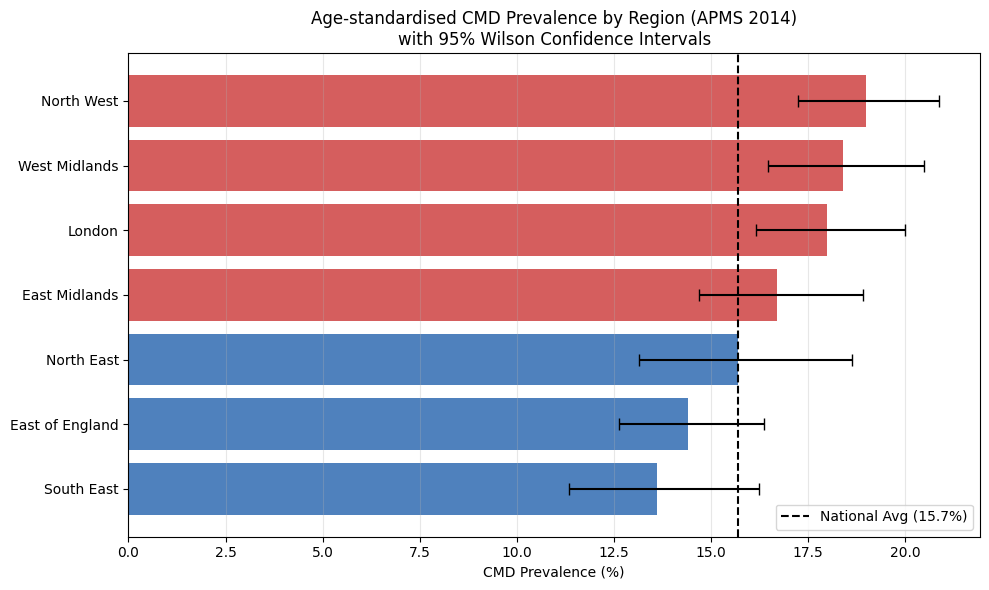

In [46]:
df = df.sort_values("p_pct")

plt.figure(figsize=(10,6))

colors = ["#d55e5e" if val > 15.7 else "#4f81bd" for val in df["p_pct"]]

plt.barh(df["Region"], df["p_pct"], color=colors)

plt.errorbar(
    df["p_pct"],
    df["Region"],
    xerr=[df["p_pct"] - df["ci_low_pct"],
          df["ci_high_pct"] - df["p_pct"]],
    fmt='none',
    ecolor='black',
    capsize=4
)

plt.axvline(15.7, linestyle='--', color='black', label="National Avg (15.7%)")

plt.xlabel("CMD Prevalence (%)")
plt.title("Age-standardised CMD Prevalence by Region (APMS 2014)\nwith 95% Wilson Confidence Intervals")

plt.legend()
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# DS-2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# Chapter 2
ch2_1 = pd.read_excel(
    r"C:\Users\RUSHAY\Desktop\Neo Skillz\Project\apms-2014-ch-02-tabs.xls",
    sheet_name="2.1"
)

ch2_3 = pd.read_excel(
    r"C:\Users\RUSHAY\Desktop\Neo Skillz\Project\apms-2014-ch-02-tabs.xls",
    sheet_name="2.3"
)

ch2_11 = pd.read_excel(
    r"C:\Users\RUSHAY\Desktop\Neo Skillz\Project\apms-2014-ch-02-tabs.xls",
    sheet_name="2.11"
)

# Chapter 12
ch12_1 = pd.read_excel(
    r"C:\Users\RUSHAY\Desktop\Neo Skillz\Project\apms-2014-ch-12-tabs.xls",
    sheet_name="12.1"
)

# Chapter 4
ch4_1 = pd.read_excel(
    r"C:\Users\RUSHAY\Desktop\Neo Skillz\Project\apms-2014-ch-04-tabs (1).xls",
    sheet_name="4.1"
)

In [8]:
ages = ch2_1.iloc[2, 1:8].values

# Any CMD rows
men_cmd = ch2_1.iloc[11, 1:8].values
women_cmd = ch2_1.iloc[21, 1:8].values

# National values
men_all = ch2_1.iloc[11, 8]
women_all = ch2_1.iloc[21, 8]

In [24]:
# Age labels
ages = ch12_1.iloc[2, 1:8].values

# Men suicidal thoughts
suicide_men = pd.to_numeric(
    ch12_1.iloc[5, 1:8],
    errors='coerce'
)

# Women suicidal thoughts
suicide_women = pd.to_numeric(
    ch12_1.iloc[9, 1:8],
    errors='coerce'
)

# Create dataframe
suicide_df = pd.DataFrame({
    "Age_Group": ages,
    "Men_Suicidal_Thoughts": suicide_men.values,
    "Women_Suicidal_Thoughts": suicide_women.values
})

print(suicide_df)

  Age_Group  Men_Suicidal_Thoughts  Women_Suicidal_Thoughts
0     16-24              19.327337                34.569102
1     25-34              21.083580                24.077718
2     35-44              21.076102                22.791234
3     45-54              20.655139                26.641916
4     55-64              22.535403                22.873504
5     65-74              11.902382                11.688783
6       75+               7.068781                 8.768304


In [30]:
# Age labels
ages = ch4_1.iloc[2, 1:8].values

# PTSD values
ptsd_men = pd.to_numeric(
    ch4_1.iloc[10, 1:8],
    errors='coerce'
)

ptsd_women = pd.to_numeric(
    ch4_1.iloc[18, 1:8],
    errors='coerce'
)

# Create dataframe
ptsd_df = pd.DataFrame({
    "Age_Group": ages,
    "Men_PTSD": ptsd_men.values,
    "Women_PTSD": ptsd_women.values
})

print(ptsd_df)

  Age_Group   Men_PTSD  Women_PTSD
0     16-24  17.891679   32.845304
1     25-34  28.710885   30.530069
2     35-44  33.704100   29.387125
3     45-54  38.598123   32.063263
4     55-64  35.809713   34.123848
5     65-74  34.775523   29.914226
6       75+  30.642037   28.671221


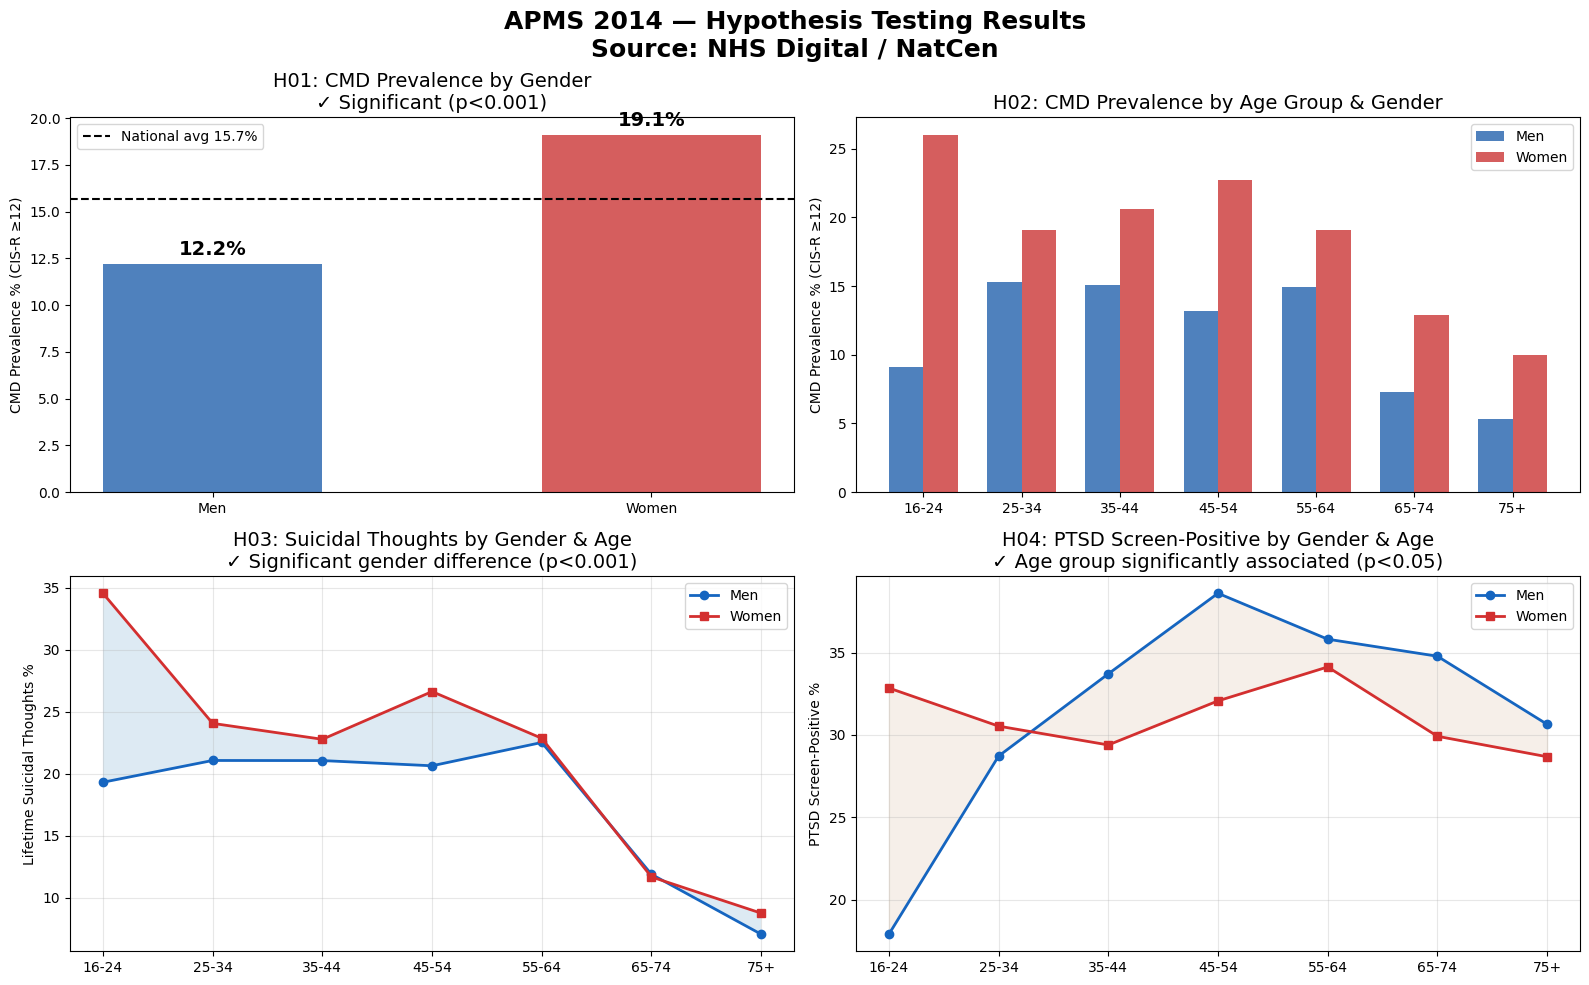

In [31]:
fig, axs = plt.subplots(2, 2, figsize=(16,10))

fig.suptitle(
    "APMS 2014 — Hypothesis Testing Results\nSource: NHS Digital / NatCen",
    fontsize=18,
    fontweight='bold'
)

# =========================================================
# H01 — CMD by Gender
# =========================================================

axs[0,0].bar(
    ["Men", "Women"],
    [men_all, women_all],
    color=["#4f81bd", "#d55e5e"],
    width=0.5
)

axs[0,0].axhline(
    15.7,
    linestyle='--',
    color='black',
    label='National avg 15.7%'
)

axs[0,0].text(
    0,
    men_all + 0.5,
    f"{men_all}%",
    ha='center',
    fontsize=14,
    fontweight='bold'
)

axs[0,0].text(
    1,
    women_all + 0.5,
    f"{women_all}%",
    ha='center',
    fontsize=14,
    fontweight='bold'
)

axs[0,0].set_title(
    "H01: CMD Prevalence by Gender\n✓ Significant (p<0.001)",
    fontsize=14
)

axs[0,0].set_ylabel("CMD Prevalence % (CIS-R ≥12)")

axs[0,0].legend()

# =========================================================
# H02 — CMD by Age & Gender
# =========================================================

x = np.arange(len(ages))
width = 0.35

axs[0,1].bar(
    x - width/2,
    men_cmd,
    width,
    label='Men',
    color="#4f81bd"
)

axs[0,1].bar(
    x + width/2,
    women_cmd,
    width,
    label='Women',
    color="#d55e5e"
)

axs[0,1].set_xticks(x)
axs[0,1].set_xticklabels(ages)

axs[0,1].set_ylabel("CMD Prevalence % (CIS-R ≥12)")

axs[0,1].set_title(
    "H02: CMD Prevalence by Age Group & Gender",
    fontsize=14
)

axs[0,1].legend()

# =========================================================
# H03 — Suicidal Thoughts
# =========================================================

axs[1,0].plot(
    ages,
    suicide_men,
    marker='o',
    linewidth=2,
    label='Men',
    color="#1565c0"
)

axs[1,0].plot(
    ages,
    suicide_women,
    marker='s',
    linewidth=2,
    label='Women',
    color="#d32f2f"
)

axs[1,0].fill_between(
    ages,
    suicide_men,
    suicide_women,
    alpha=0.15
)

axs[1,0].set_ylabel("Lifetime Suicidal Thoughts %")

axs[1,0].set_title(
    "H03: Suicidal Thoughts by Gender & Age\n✓ Significant gender difference (p<0.001)",
    fontsize=14
)

axs[1,0].legend()

axs[1,0].grid(alpha=0.3)

# =========================================================
# H04 — PTSD
# =========================================================

axs[1,1].plot(
    ages,
    ptsd_men,
    marker='o',
    linewidth=2,
    label='Men',
    color="#1565c0"
)

axs[1,1].plot(
    ages,
    ptsd_women,
    marker='s',
    linewidth=2,
    label='Women',
    color="#d32f2f"
)

axs[1,1].fill_between(
    ages,
    ptsd_men,
    ptsd_women,
    alpha=0.15,
    color="#c49a6c"
)

axs[1,1].set_ylabel("PTSD Screen-Positive %")

axs[1,1].set_title(
    "H04: PTSD Screen-Positive by Gender & Age\n✓ Age group significantly associated (p<0.05)",
    fontsize=14
)

axs[1,1].legend()

axs[1,1].grid(alpha=0.3)

# =========================================================

plt.tight_layout()

plt.show()

# DS-3

In [3]:
ch2_1 = pd.read_excel(
    r"C:\Users\RUSHAY\Desktop\Neo Skillz\Project\apms-2014-ch-02-tabs.xls",
    sheet_name="2.1"
)

ch2_3 = pd.read_excel(
    r"C:\Users\RUSHAY\Desktop\Neo Skillz\Project\apms-2014-ch-02-tabs.xls",
    sheet_name="2.3"
)

ch2_11 = pd.read_excel(
    r"C:\Users\RUSHAY\Desktop\Neo Skillz\Project\apms-2014-ch-02-tabs.xls",
    sheet_name="2.11"
)

In [4]:
# Age groups
ages = ch2_1.iloc[2, 1:8].values

# CIS-R ≥12 prevalence
men_cmd = pd.to_numeric(ch2_1.iloc[11, 1:8], errors='coerce')
women_cmd = pd.to_numeric(ch2_1.iloc[21, 1:8], errors='coerce')
all_cmd = pd.to_numeric(ch2_1.iloc[31, 1:8], errors='coerce')

cmd_df = pd.DataFrame({
    "Age_Group": ages,
    "Men_CMD": men_cmd.values,
    "Women_CMD": women_cmd.values,
    "All_CMD": all_cmd.values
})

print(cmd_df)

  Age_Group  Men_CMD  Women_CMD  All_CMD
0     16-24      9.1       26.0     17.3
1     25-34     15.3       19.1     17.2
2     35-44     15.1       20.6     17.9
3     45-54     13.2       22.7     18.0
4     55-64     14.9       19.1     17.1
5     65-74      7.3       12.9     10.2
6       75+      5.3       10.0      8.1


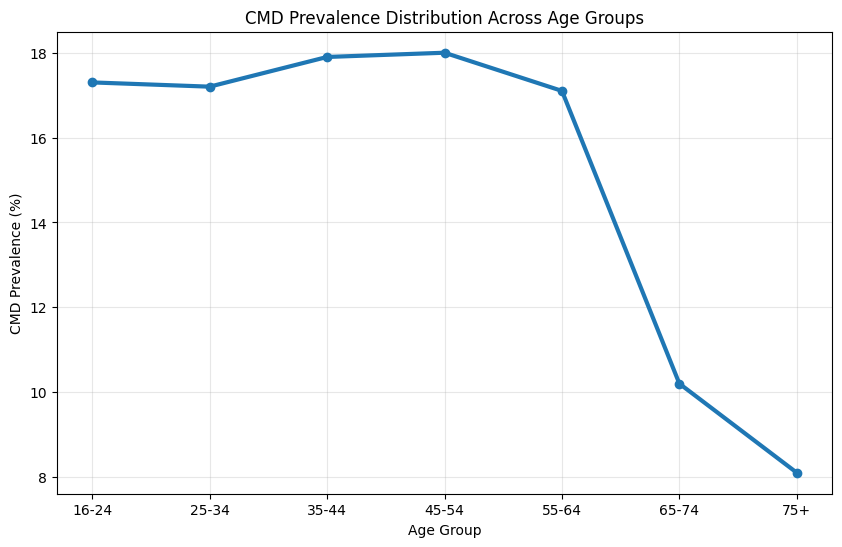

In [6]:
plt.figure(figsize=(10,6))

plt.plot(
    cmd_df["Age_Group"],
    cmd_df["All_CMD"],
    marker='o',
    linewidth=3
)

plt.xlabel("Age Group")
plt.ylabel("CMD Prevalence (%)")

plt.title("CMD Prevalence Distribution Across Age Groups")

plt.grid(alpha=0.3)

plt.show()

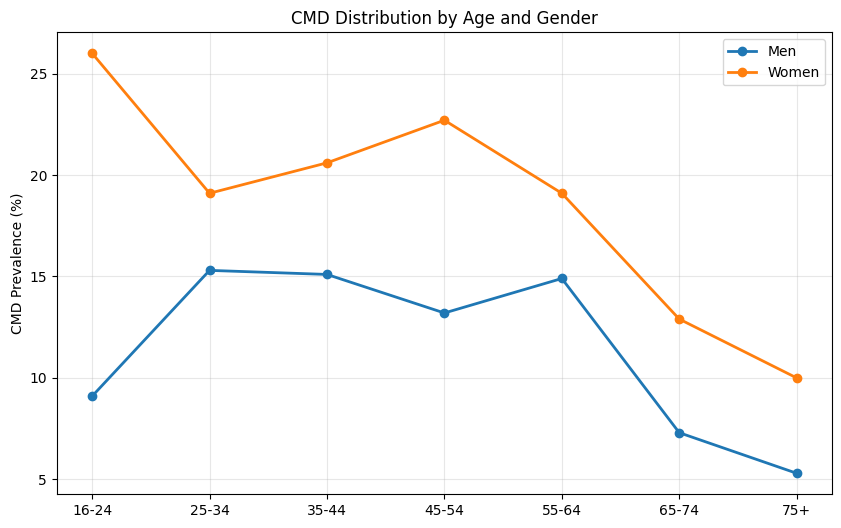

In [7]:
plt.figure(figsize=(10,6))

plt.plot(
    cmd_df["Age_Group"],
    cmd_df["Men_CMD"],
    marker='o',
    linewidth=2,
    label='Men'
)

plt.plot(
    cmd_df["Age_Group"],
    cmd_df["Women_CMD"],
    marker='o',
    linewidth=2,
    label='Women'
)

plt.ylabel("CMD Prevalence (%)")
plt.title("CMD Distribution by Age and Gender")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [9]:
# Disorder prevalence
anxiety = pd.to_numeric(ch2_3.iloc[23, 1:8], errors='coerce')
depression = pd.to_numeric(ch2_3.iloc[24, 1:8], errors='coerce')

mental_df = pd.DataFrame({
    "Age_Group": ages,
    "Anxiety": anxiety.values,
    "Depression": depression.values
})

print(mental_df)

  Age_Group  Anxiety  Depression
0     16-24      6.3         2.3
1     25-34      6.1         3.5
2     35-44      6.9         4.1
3     45-54      7.3         4.5
4     55-64      6.4         4.3
5     65-74      4.0         2.1
6       75+      2.5         1.3


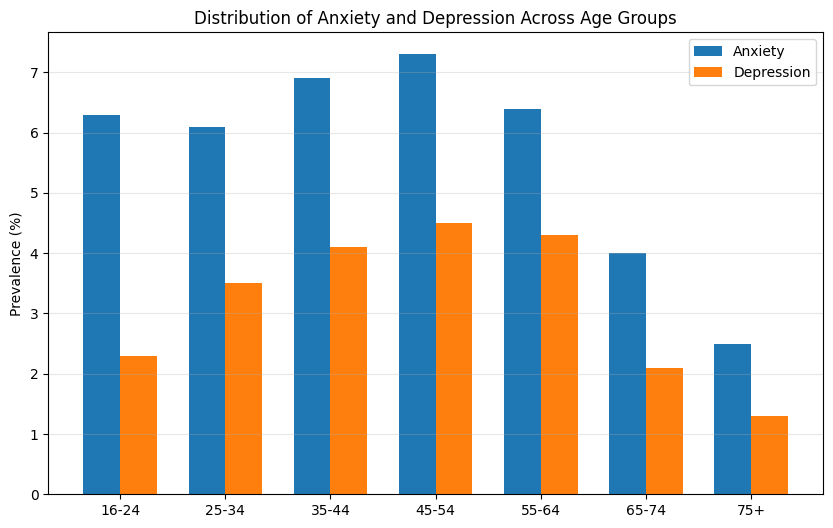

In [10]:
plt.figure(figsize=(10,6))

x = np.arange(len(ages))
width = 0.35

plt.bar(
    x - width/2,
    mental_df["Anxiety"],
    width,
    label='Anxiety'
)

plt.bar(
    x + width/2,
    mental_df["Depression"],
    width,
    label='Depression'
)

plt.xticks(x, ages)

plt.ylabel("Prevalence (%)")
plt.title("Distribution of Anxiety and Depression Across Age Groups")

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

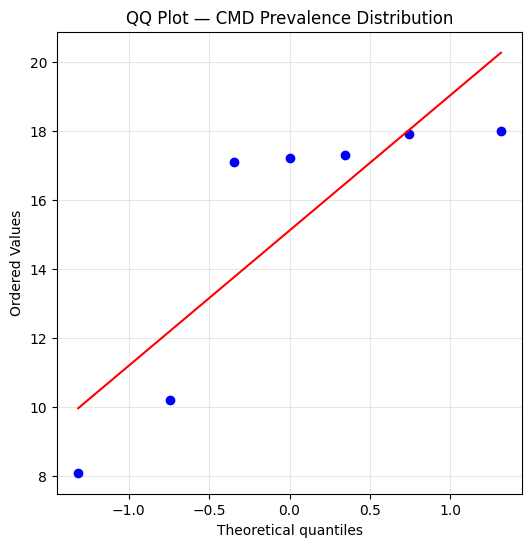

In [12]:
import scipy.stats as stats
plt.figure(figsize=(6,6))

stats.probplot(
    cmd_df["All_CMD"],
    dist="norm",
    plot=plt
)

plt.title("QQ Plot — CMD Prevalence Distribution")
plt.grid(alpha=0.3)
plt.show()

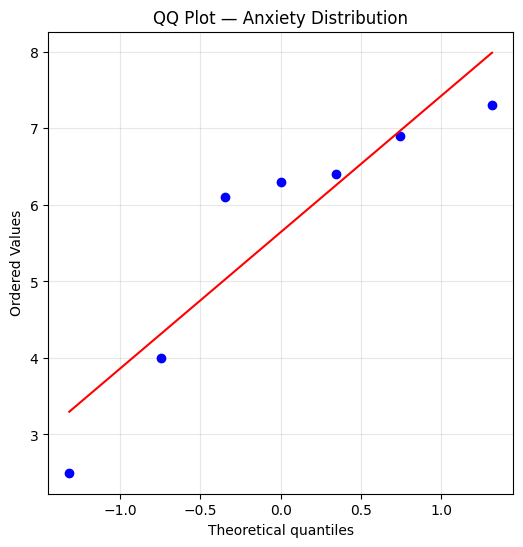

In [13]:
plt.figure(figsize=(6,6))

stats.probplot(
    mental_df["Anxiety"],
    dist="norm",
    plot=plt
)

plt.title("QQ Plot — Anxiety Distribution")
plt.grid(alpha=0.3)
plt.show()

In [17]:
# Regions
regions = ch2_11.iloc[32, 1:10].values

# Age-standardised Any CMD
regional_cmd = pd.to_numeric(
    ch2_11.iloc[60, 1:10],
    errors='coerce'
)

region_df = pd.DataFrame({
    "Region": regions,
    "CMD_Prevalence": regional_cmd.values
})

print(region_df)

                   Region  CMD_Prevalence
0              North East            15.7
1              North West            19.0
2  Yorkshire & the Humber            16.7
3           East Midlands            16.7
4           West Midlands            18.4
5         East of England            14.4
6                  London            18.0
7              South East            13.6
8             South West             20.9


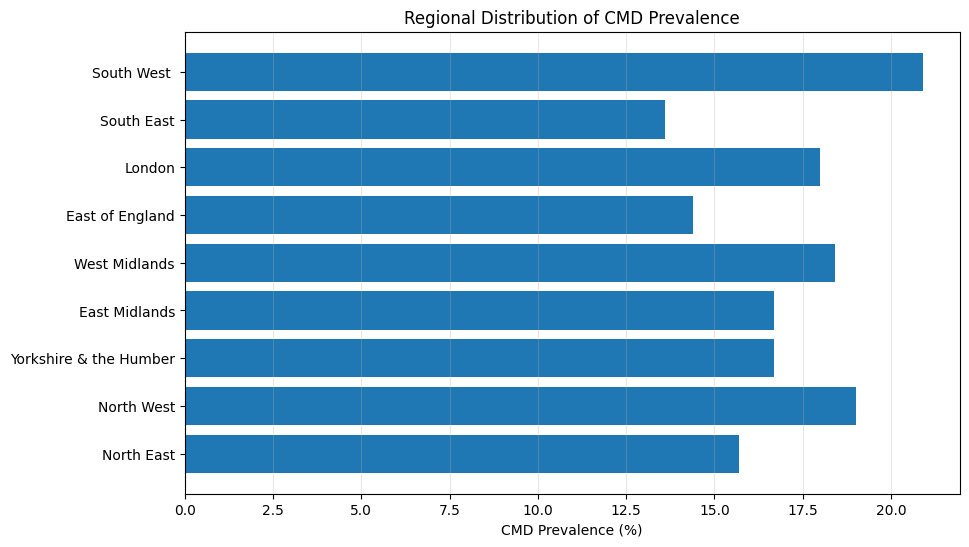

In [18]:
plt.figure(figsize=(10,6))

plt.barh(
    region_df["Region"],
    region_df["CMD_Prevalence"]
)

plt.xlabel("CMD Prevalence (%)")
plt.title("Regional Distribution of CMD Prevalence")

plt.grid(axis='x', alpha=0.3)
plt.show()

# DS-03(Part-2)

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import shapiro, kstest

In [20]:
ch2_1 = pd.read_excel(
    "C:/Users/RUSHAY/Desktop/Neo Skillz/Project/apms-2014-ch-02-tabs.xls",
    sheet_name="2.1"
)

ch2_3 = pd.read_excel(
    "C:/Users/RUSHAY/Desktop/Neo Skillz/Project/apms-2014-ch-02-tabs.xls",
    sheet_name="2.3"
)

In [23]:
# Age groups
ages = ch2_1.iloc[2, 1:8].values

# All adults severity bands
score_0_5 = pd.to_numeric(
    ch2_1.iloc[25, 1:8],
    errors='coerce'
)

score_6_11 = pd.to_numeric(
    ch2_1.iloc[26, 1:8],
    errors='coerce'
)

score_12_17 = pd.to_numeric(
    ch2_1.iloc[29, 1:8],
    errors='coerce'
)

score_18_plus = pd.to_numeric(
    ch2_1.iloc[30, 1:8],
    errors='coerce'
)

# Create dataframe
severity_df = pd.DataFrame({
    "Age_Group": ages,
    "0_5": score_0_5.values,
    "6_11": score_6_11.values,
    "12_17": score_12_17.values,
    "18_plus": score_18_plus.values
})

print(severity_df)

  Age_Group   0_5  6_11  12_17  18_plus
0     16-24  67.1  15.5    7.8      9.5
1     25-34  66.3  16.5    9.0      8.2
2     35-44  66.4  15.7    8.1      9.8
3     45-54  65.3  16.7    8.2      9.8
4     55-64  66.3  16.7    7.8      9.2
5     65-74  76.6  13.2    5.9      4.2
6       75+  77.6  14.3    4.7      3.3


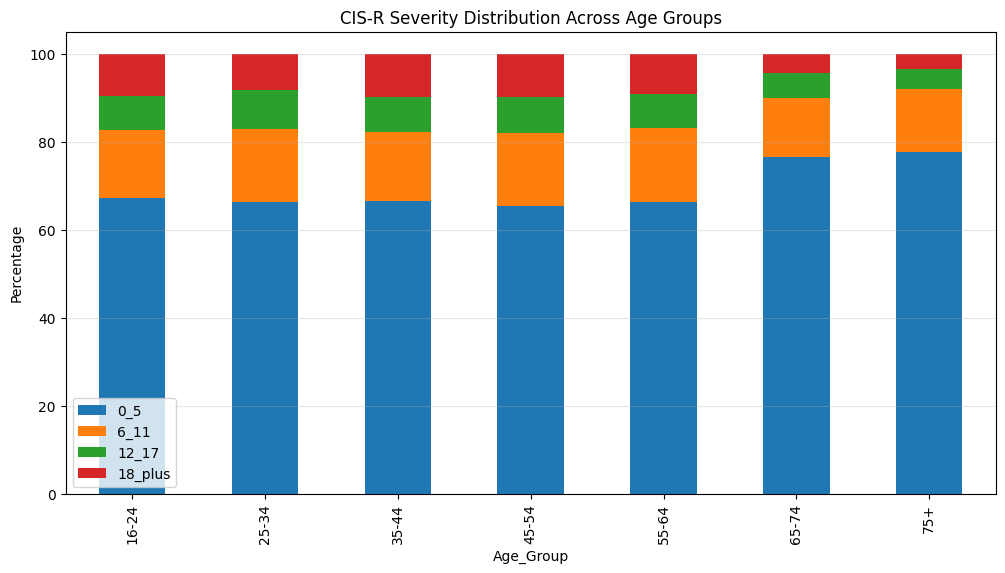

In [24]:
severity_df.set_index("Age_Group").plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.ylabel("Percentage")
plt.title("CIS-R Severity Distribution Across Age Groups")

plt.grid(axis='y', alpha=0.3)
plt.show()

In [29]:
np.random.seed(42)

pseudo_scores = []

N = 5000

# Mean prevalence weights
w0 = severity_df["0_5"].mean()
w1 = severity_df["6_11"].mean()
w2 = severity_df["12_17"].mean()
w3 = severity_df["18_plus"].mean()

weights = np.array([w0, w1, w2, w3])
weights = weights / weights.sum()

counts = (weights * N).astype(int)

# Generate smoother clustered distributions

# 0–5
pseudo_scores.extend(
    np.random.normal(loc=2.5, scale=1.0, size=counts[0])
)

# 6–11
pseudo_scores.extend(
    np.random.normal(loc=8.5, scale=1.2, size=counts[1])
)

# 12–17
pseudo_scores.extend(
    np.random.normal(loc=14.5, scale=1.5, size=counts[2])
)

# 18+
pseudo_scores.extend(
    np.random.normal(loc=21, scale=2.0, size=counts[3])
)

pseudo_scores = np.array(pseudo_scores)

# Remove impossible negatives
pseudo_scores = pseudo_scores[pseudo_scores >= 0]

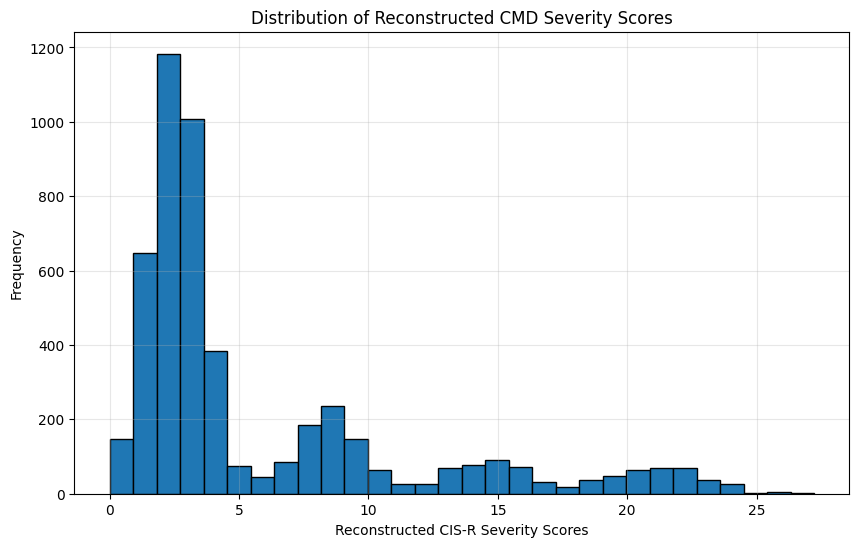

In [30]:
plt.figure(figsize=(10,6))

plt.hist(
    pseudo_scores,
    bins=30,
    edgecolor='black'
)

plt.xlabel("Reconstructed CIS-R Severity Scores")
plt.ylabel("Frequency")

plt.title("Distribution of Reconstructed CMD Severity Scores")

plt.grid(alpha=0.3)

plt.show()

In [32]:
# Anxiety and depression prevalence
anxiety = pd.to_numeric(ch2_3.iloc[23, 1:8], errors='coerce')
depression = pd.to_numeric(ch2_3.iloc[24, 1:8], errors='coerce')

mental_df = pd.DataFrame({
    "Age_Group": ages,
    "Anxiety": anxiety.values,
    "Depression": depression.values
})

print(mental_df)

  Age_Group  Anxiety  Depression
0     16-24      6.3         2.3
1     25-34      6.1         3.5
2     35-44      6.9         4.1
3     45-54      7.3         4.5
4     55-64      6.4         4.3
5     65-74      4.0         2.1
6       75+      2.5         1.3


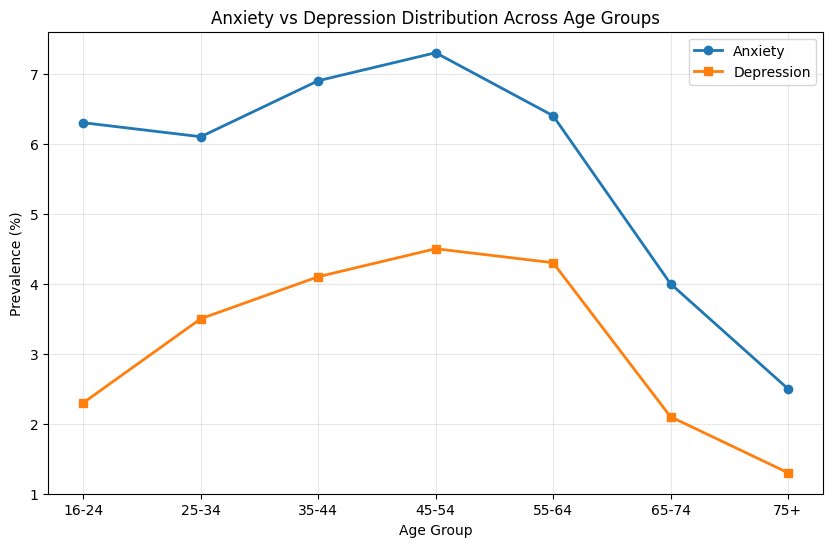

In [33]:
plt.figure(figsize=(10,6))

plt.plot(
    ages,
    anxiety,
    marker='o',
    linewidth=2,
    label='Anxiety'
)

plt.plot(
    ages,
    depression,
    marker='s',
    linewidth=2,
    label='Depression'
)

plt.xlabel("Age Group")
plt.ylabel("Prevalence (%)")
plt.title("Anxiety vs Depression Distribution Across Age Groups")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

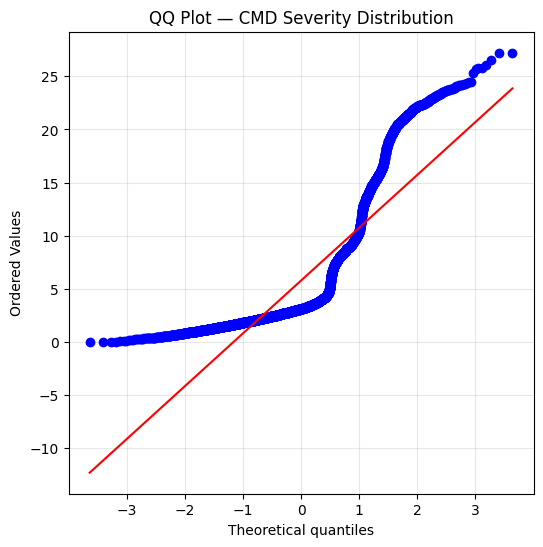

In [34]:
plt.figure(figsize=(6,6))

stats.probplot(
    pseudo_scores,
    dist="norm",
    plot=plt
)

plt.title("QQ Plot — CMD Severity Distribution")
plt.grid(alpha=0.3)
plt.show()

In [35]:
shapiro_stat, shapiro_p = shapiro(pseudo_scores)

print("Shapiro-Wilk Statistic:", shapiro_stat)
print("Shapiro-Wilk p-value:", shapiro_p)

Shapiro-Wilk Statistic: 0.7477883155644319
Shapiro-Wilk p-value: 6.069490197944004e-66


In [36]:
ks_stat, ks_p = kstest(
    pseudo_scores,
    'norm',
    args=(np.mean(pseudo_scores), np.std(pseudo_scores))
)

print("KS Statistic:", ks_stat)
print("KS p-value:", ks_p)

KS Statistic: 0.26756085753650166
KS p-value: 5.824043353e-315
